<a href="https://colab.research.google.com/github/avijitdutta1230000-crypto/avijit.github.io/blob/main/Honeywell_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faker -q

import numpy as np
import pandas as pd
from faker import Faker
import random
from datetime import datetime, timedelta
import uuid

fake = Faker()
np.random.seed(42)
random.seed(42)

# Mount Google Drive to persist data across sessions
from google.colab import drive
drive.mount('/content/drive')

# Create a working folder
import os
PROJECT_DIR = '/content/drive/MyDrive/anomaly_detection_project'
os.makedirs(PROJECT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
NUM_USERS = 500
NUM_DEVICES = 150
SIM_DAYS = 60

def generate_entities(num_users, num_devices):
    entities = []
    for i in range(num_users):
        entities.append({
            'entity_id': f'user_{i:04d}',
            'entity_type': random.choice(['user']*9 + ['service_account']),
            'home_geo': fake.city(),
            'home_ip_prefix': f"10.{random.randint(0,255)}.{random.randint(0,255)}",
            'typical_start_hour': np.random.normal(9, 1.5),
            'typical_end_hour': np.random.normal(18, 1.5),
            'auth_method': random.choice(['password', 'oauth_token', 'certificate']),
            'usual_resources': random.sample(
                ['file_server', 'db_prod', 'db_staging', 'hr_portal',
                 'code_repo', 'billing_system', 'email', 'crm', 'vpn_gateway'],
                k=random.randint(2, 4)
            )
        })
    for i in range(num_devices):
        entities.append({
            'entity_id': f'device_{i:04d}',
            'entity_type': 'edge_device',
            'home_geo': fake.city(),
            'home_ip_prefix': f"192.168.{random.randint(0,255)}",
            'typical_start_hour': 0,
            'typical_end_hour': 24,
            'auth_method': 'certificate',
            'usual_resources': random.sample(
                ['sensor_gateway', 'telemetry_db', 'firmware_server'], k=2
            )
        })
    return entities

entities = generate_entities(NUM_USERS, NUM_DEVICES)
entity_df = pd.DataFrame(entities)
entity_df.head()

,entity_id,entity_type,home_geo,home_ip_prefix,typical_start_hour,typical_end_hour,auth_method,usual_resources
0,user_0000,user,Port Tiffanyshire,10.12.140,9.745071,17.792604,password,"[db_staging, db_prod]"
1,user_0001,user,Lake Toddtown,10.44.216,9.971533,20.284545,password,"[db_prod, hr_portal]"
2,user_0002,user,Brittanyfort,10.13.101,8.648770,17.648795,certificate,"[vpn_gateway, email, db_prod, hr_portal]"
3,user_0003,service_account,Johnstonfurt,10.142.3,11.368819,19.151152,password,"[email, billing_system, db_staging, db_prod]"
4,user_0004,user,Port Danielle,10.172.52,8.295788,18.813840,password,"[db_prod, billing_system, email]"


In [ ]:
def generate_entities(num_users, num_devices):
    entities = []
    for i in range(num_users):
        entities.append({
            'entity_id': f'user_{i:04d}',
            'entity_type': random.choice(['user'] * 9 + ['service_account']),
            'home_geo': fake.city(),
            'home_ip_prefix': f"10.{random.randint(0, 255)}.{random.randint(0, 255)}",
            'typical_start_hour': np.random.normal(9, 1.5),
            'typical_end_hour': np.random.normal(18, 1.5),
            'auth_method': random.choice(['password', 'oauth_token', 'certificate']),
            'usual_resources': random.sample(
                ['file_server', 'db_prod', 'db_staging', 'hr_portal',
                 'code_repo', 'billing_system', 'email', 'crm', 'vpn_gateway'],
                k=random.randint(2, 4)
            ),
            'device_fingerprint': f"OS:{random.choice(['Win11', 'MacOS', 'Win10'])}|MAC:{fake.mac_address()}"
        })
    for i in range(num_devices):
        entities.append({
            'entity_id': f'device_{i:04d}',
            'entity_type': 'edge_device',
            'home_geo': fake.city(),
            'home_ip_prefix': f"192.168.{random.randint(0, 255)}",
            'typical_start_hour': 0,
            'typical_end_hour': 24,
            'auth_method': 'certificate',
            'usual_resources': random.sample(
                ['sensor_gateway', 'telemetry_db', 'firmware_server'], k=2
            ),
            'device_fingerprint': f"OS:Linux|MAC:{fake.mac_address()}"
        })
    return entities

def generate_normal_logs(entity, sim_days):
    logs = []
    start_date = datetime(2026, 1, 1)

    for day in range(sim_days):
        current_date = start_date + timedelta(days=day)

        # Calculate daily event volume within the day loop so it fluctuates daily
        events_per_day = np.random.poisson(6) if entity['entity_type'] != 'edge_device' else np.random.poisson(50)

        # Weekends: fewer events for human users
        if entity['entity_type'] == 'user' and current_date.weekday() >= 5:
            if random.random() > 0.1:
                continue

        n_events = max(0, int(np.random.poisson(events_per_day)))
        for _ in range(n_events):
            hour = np.clip(np.random.normal(
                (entity['typical_start_hour'] + entity['typical_end_hour']) / 2, 2), 0, 23)
            timestamp = current_date + timedelta(hours=hour, minutes=random.randint(0, 59))
            logs.append({
                'entity_id': entity['entity_id'],
                'entity_type': entity['entity_type'],
                'timestamp': timestamp,
                'source_ip': f"{entity['home_ip_prefix']}.{random.randint(1, 254)}",
                'geo_location': entity['home_geo'],
                'resource_accessed': random.choice(entity['usual_resources']),
                'auth_method': entity['auth_method'],
                'session_duration': max(1, int(np.random.normal(30, 15))),
                'command_sequence': random.choice([['read'], ['read', 'write'], ['login', 'read', 'logout']]),
                'device_fingerprint': entity['device_fingerprint'],
                'label': 'normal'
            })
    return logs

all_logs = []
entities = generate_entities(NUM_USERS, NUM_DEVICES)
for entity in entities:
    all_logs.extend(generate_normal_logs(entity, SIM_DAYS))
print(f"Generated {len(all_logs)} normal log events")

Generated 589339 normal log events


In [ ]:
print(f"Number of rows in the dataset: {len(full_df)}")

Number of rows in the dataset: 598950


In [ ]:
def inject_brute_force(logs, entities, n_attacks=15):
    injected = []
    for _ in range(n_attacks):
        target = random.choice(entities)
        attack_ip = fake.ipv4()
        start = datetime(2026, 1, 1) + timedelta(days=random.randint(0, SIM_DAYS - 1), hours=random.randint(0, 23))
        for i in range(random.randint(10, 40)):
            injected.append({
                'entity_id': target['entity_id'],
                'entity_type': target['entity_type'],
                'timestamp': start + timedelta(seconds=i * random.randint(2, 10)),
                'source_ip': attack_ip,
                'geo_location': fake.city(),  # Unified to city level
                'resource_accessed': 'login_endpoint',
                'auth_method': target['auth_method'],
                'session_duration': 0,
                'command_sequence': ['failed_login'],
                'device_fingerprint': f"OS:Unknown|MAC:{fake.mac_address()}",
                'label': 'brute_force'
            })
    return injected

def inject_impossible_travel(logs, entities, n_attacks=10):
    injected = []
    for _ in range(n_attacks):
        target = random.choice(entities)
        t1 = datetime(2026, 1, 1) + timedelta(days=random.randint(0, SIM_DAYS - 1), hours=random.randint(0, 23))
        t2 = t1 + timedelta(minutes=random.randint(5, 30))  # Impossible speed between cities
        for ts, geo in [(t1, target['home_geo']), (t2, fake.city())]:  # Unified to city level
            injected.append({
                'entity_id': target['entity_id'],
                'entity_type': target['entity_type'],
                'timestamp': ts,
                'source_ip': fake.ipv4(),
                'geo_location': geo,
                'resource_accessed': random.choice(target['usual_resources']),
                'auth_method': target['auth_method'],
                'session_duration': random.randint(10, 60),
                'command_sequence': ['login', 'read'],
                'device_fingerprint': f"OS:Win11|MAC:{fake.mac_address()}",
                'label': 'impossible_travel'
            })
    return injected

def inject_credential_stuffing(logs, entities, n_campaigns=8):
    injected = []
    for _ in range(n_campaigns):
        pool_ips = [fake.ipv4() for _ in range(3)]
        start = datetime(2026, 1, 1) + timedelta(days=random.randint(0, SIM_DAYS - 1))
        targets = random.sample(entities, k=min(30, len(entities)))
        for t in targets:
            injected.append({
                'entity_id': t['entity_id'],
                'entity_type': t['entity_type'],
                'timestamp': start + timedelta(seconds=random.randint(0, 3600)),
                'source_ip': random.choice(pool_ips),
                'geo_location': fake.city(),  # Unified to city level
                'resource_accessed': 'login_endpoint',
                'auth_method': t['auth_method'],
                'session_duration': 0,
                'command_sequence': ['failed_login'],
                'device_fingerprint': f"OS:Unknown|MAC:{fake.mac_address()}",
                'label': 'credential_stuffing'
            })
    return injected

def inject_lateral_movement(logs, entities, n_attacks=10):
    injected = []
    all_resources = ['file_server', 'db_prod', 'db_staging', 'hr_portal', 'code_repo',
                     'billing_system', 'email', 'crm', 'vpn_gateway']
    for _ in range(n_attacks):
        target = random.choice(entities)
        start = datetime(2026, 1, 1) + timedelta(days=random.randint(0, SIM_DAYS - 1))
        unusual = [r for r in all_resources if r not in target['usual_resources']]
        for i, res in enumerate(random.sample(unusual, k=min(5, len(unusual)))):
            injected.append({
                'entity_id': target['entity_id'],
                'entity_type': target['entity_type'],
                'timestamp': start + timedelta(minutes=i * 5),
                'source_ip': f"{target['home_ip_prefix']}.{random.randint(1, 254)}",
                'geo_location': target['home_geo'],
                'resource_accessed': res,
                'auth_method': target['auth_method'],
                'session_duration': random.randint(20, 90),
                'command_sequence': ['login', 'read', 'write', 'export'],
                'device_fingerprint': f"OS:Win11|MAC:{fake.mac_address()}",
                'label': 'lateral_movement'
            })
    return injected

def inject_device_spoofing(logs, entities, n_attacks=10):
    injected = []
    for _ in range(n_attacks):
        target = random.choice(entities)
        ts = datetime(2026, 1, 1) + timedelta(days=random.randint(0, SIM_DAYS - 1), hours=random.randint(0, 23))
        injected.append({
            'entity_id': target['entity_id'],
            'entity_type': target['entity_type'],
            'timestamp': ts,
            'source_ip': fake.ipv4(),
            'geo_location': target['home_geo'],
            'resource_accessed': random.choice(target['usual_resources']),
            'auth_method': target['auth_method'],
            'session_duration': random.randint(10, 60),
            'command_sequence': ['login', 'read'],
            'device_fingerprint': f"OS:{random.choice(['Linux', 'Android', 'Unknown'])}|MAC:{fake.mac_address()}",
            'label': 'device_spoofing'
        })
    return injected

def inject_exfiltration(logs, entities, n_attacks=8):
    injected = []
    for _ in range(n_attacks):
        target = random.choice(entities)
        for day in range(random.randint(10, 20)):
            ts = datetime(2026, 1, 1) + timedelta(days=day, hours=random.choice([1, 2, 3, 23]))
            injected.append({
                'entity_id': target['entity_id'],
                'entity_type': target['entity_type'],
                'timestamp': ts,
                'source_ip': f"{target['home_ip_prefix']}.{random.randint(1, 254)}",
                'geo_location': target['home_geo'],
                'resource_accessed': random.choice(target['usual_resources']),
                'auth_method': target['auth_method'],
                'session_duration': random.randint(5, 15),
                'command_sequence': ['login', 'read', 'export'],
                'device_fingerprint': f"OS:Win11|MAC:{fake.mac_address()}",
                'label': 'low_slow_exfiltration'
            })
    return injected

attack_logs = []
attack_logs += inject_brute_force(all_logs, entities, n_attacks=45)
attack_logs += inject_impossible_travel(all_logs, entities, n_attacks=500)
attack_logs += inject_credential_stuffing(all_logs, entities, n_campaigns=35)
attack_logs += inject_lateral_movement(all_logs, entities, n_attacks=200)
attack_logs += inject_device_spoofing(all_logs, entities, n_attacks=1000)
attack_logs += inject_exfiltration(all_logs, entities, n_attacks=65)

print(f"Generated {len(attack_logs)} attack events")
print(f"Attack ratio: {len(attack_logs) / (len(all_logs) + len(attack_logs)) * 100:.2f}%")

Generated 6233 attack events
Attack ratio: 1.05%


In [ ]:
full_df = pd.DataFrame(all_logs + attack_logs)
full_df = full_df.sort_values('timestamp').reset_index(drop=True)
full_df['event_id'] = [str(uuid.uuid4()) for _ in range(len(full_df))]

print(full_df['label'].value_counts())
print(f"\nTotal events: {len(full_df)}")

# Save to Drive
full_df.to_csv(f'{PROJECT_DIR}/synthetic_access_logs.csv', index=False)
print(f"Saved to {PROJECT_DIR}/synthetic_access_logs.csv")

label
normal                   589339
brute_force                1206
credential_stuffing        1050
impossible_travel          1000
lateral_movement           1000
device_spoofing            1000
low_slow_exfiltration       977
Name: count, dtype: int64

Total events: 595572
Saved to /content/drive/MyDrive/anomaly_detection_project/synthetic_access_logs.csv


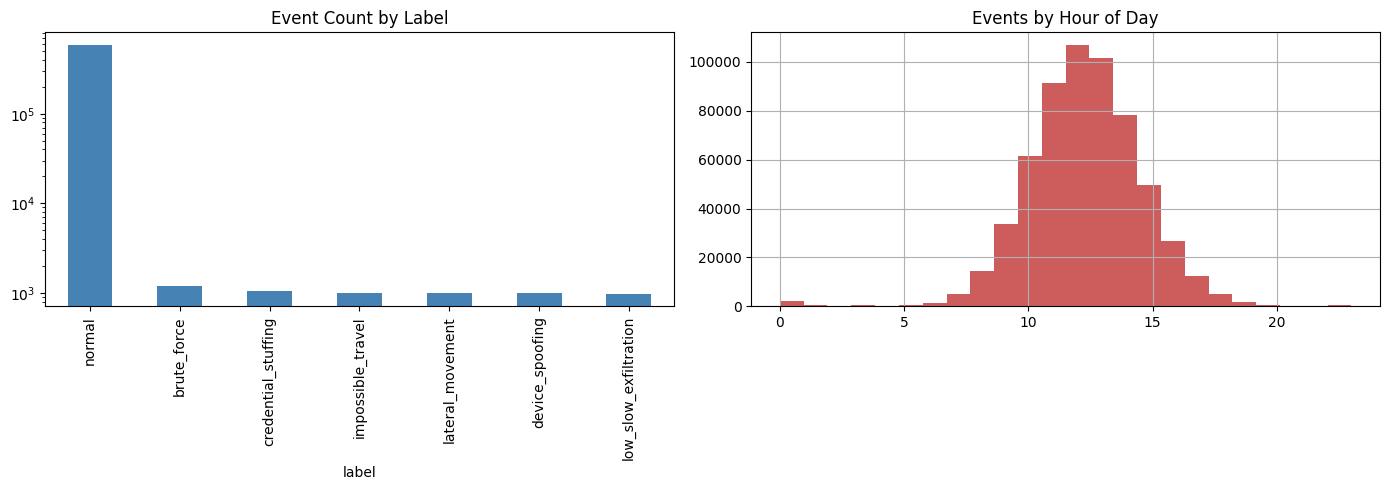

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

full_df['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Event Count by Label')
axes[0].set_yscale('log')

full_df['timestamp'].dt.hour.hist(bins=24, ax=axes[1], color='indianred')
axes[1].set_title('Events by Hour of Day')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

full_df = pd.read_csv(f'{PROJECT_DIR}/synthetic_access_logs.csv', parse_dates=['timestamp'])
full_df = full_df.sort_values('timestamp').reset_index(drop=True)

# Time-based features
full_df['hour'] = full_df['timestamp'].dt.hour
full_df['day_of_week'] = full_df['timestamp'].dt.dayofweek
full_df['is_weekend'] = (full_df['day_of_week'] >= 5).astype(int)

# Resource diversity per entity (rolling, computed later) — for now, basic encodings
from sklearn.preprocessing import LabelEncoder

le_resource = LabelEncoder()
le_auth = LabelEncoder()
le_geo = LabelEncoder()

full_df['resource_enc'] = le_resource.fit_transform(full_df['resource_accessed'])
full_df['auth_enc'] = le_auth.fit_transform(full_df['auth_method'])
full_df['geo_enc'] = le_geo.fit_transform(full_df['geo_location'])

print(full_df.shape)
full_df.head()

(595572, 18)


,entity_id,entity_type,timestamp,source_ip,geo_location,resource_accessed,auth_method,session_duration,command_sequence,device_fingerprint,label,event_id,hour,day_of_week,is_weekend,resource_enc,auth_enc,geo_enc
0,user_0154,user,2026-01-01 00:00:00,10.97.149.193,Josetown,db_prod,oauth_token,36,"['login', 'read', 'write', 'export']",OS:Win11|MAC:e2:51:f2:7e:95:8a,lateral_movement,c681c21f-0009-4858-b179-a8341c00ccef,0,3,0,3,1,990
1,user_0135,service_account,2026-01-01 00:00:00,10.138.27.172,Clarkberg,db_staging,oauth_token,45,"['login', 'read', 'write', 'export']",OS:Win11|MAC:58:98:de:4e:02:42,lateral_movement,fffa2425-83f1-4804-b72a-bee877250019,0,3,0,4,1,269
2,user_0132,user,2026-01-01 00:00:00,10.156.230.64,West Janice,email,oauth_token,57,"['login', 'read', 'write', 'export']",OS:Win11|MAC:02:97:e5:1b:a5:c7,lateral_movement,fb4af89a-ef32-44a8-aa32-6b60be8b9b30,0,3,0,5,1,2904
3,user_0020,user,2026-01-01 00:00:32,100.251.170.3,Murphymouth,login_endpoint,password,0,['failed_login'],OS:Unknown|MAC:00:48:1d:f2:10:80,credential_stuffing,1aed08fc-6914-4cf1-8ffb-7ba0f48f49b7,0,3,0,9,2,1537
4,user_0227,user,2026-01-01 00:00:51,100.251.170.3,Veronicahaven,login_endpoint,certificate,0,['failed_login'],OS:Unknown|MAC:66:9f:10:1c:56:ab,credential_stuffing,ef219437-14b7-40bc-9c55-4e6b59a52e51,0,3,0,9,0,2793


In [ ]:
# Use only the first 70% of the timeline per entity to build the "known normal" baseline.
# This simulates a real deployment where you profile historical behavior first.

cutoff_date = full_df['timestamp'].quantile(0.7)
profile_window = full_df[full_df['timestamp'] <= cutoff_date]

entity_profiles = {}

for entity_id, group in profile_window.groupby('entity_id'):
    normal_events = group[group['label'] == 'normal']
    if len(normal_events) < 5:
        continue

    entity_profiles[entity_id] = {
        'mean_hour': normal_events['hour'].mean(),
        'std_hour': max(normal_events['hour'].std(), 0.5),
        'usual_resources': set(normal_events['resource_accessed'].unique()),
        'usual_geo': set(normal_events['geo_location'].unique()),
        'usual_fingerprints': set(normal_events['device_fingerprint'].unique()),  # NEW
        'mean_session': normal_events['session_duration'].mean(),
        'std_session': max(normal_events['session_duration'].std(), 1.0),
        'entity_type': group['entity_type'].iloc[0]
    }

print(f"Built baseline profiles for {len(entity_profiles)} entities")


# Cold-start fallback: cohort-level profile by entity_type
cohort_profiles = {}
for etype, group in profile_window[profile_window['label']=='normal'].groupby('entity_type'):
    cohort_profiles[etype] = {
        'mean_hour': group['hour'].mean(),
        'std_hour': max(group['hour'].std(), 0.5),
        'mean_session': group['session_duration'].mean(),
        'std_session': max(group['session_duration'].std(), 1.0),
    }
print("Cohort fallback profiles:", list(cohort_profiles.keys()))


Built baseline profiles for 650 entities
Cohort fallback profiles: ['edge_device', 'service_account', 'user']


In [ ]:
def score_event_statistical(row):
    entity_id = row['entity_id']
    profile = entity_profiles.get(entity_id)

    if profile is None:
        profile = cohort_profiles.get(row['entity_type'])
        if profile is None:
            return 0.5

        hour_z = abs(row['hour'] - profile['mean_hour']) / profile['std_hour']
        session_z = abs(row['session_duration'] - profile['mean_session']) / profile['std_session']
        resource_score = 0.3
        geo_score = 0.3
        fingerprint_score = 0.3  # NEW - can't verify for cold-start
    else:
        hour_z = abs(row['hour'] - profile['mean_hour']) / profile['std_hour']
        session_z = abs(row['session_duration'] - profile['mean_session']) / profile['std_session']
        resource_score = 0.0 if row['resource_accessed'] in profile['usual_resources'] else 1.0
        geo_score = 0.0 if row['geo_location'] in profile['usual_geo'] else 1.0
        fingerprint_score = 0.0 if row['device_fingerprint'] in profile['usual_fingerprints'] else 1.0  # NEW

    # Rebalanced weights to make room for fingerprint signal
    score = (
        0.20 * min(hour_z / 3, 1.0) +
        0.10 * min(session_z / 3, 1.0) +
        0.20 * resource_score +
        0.20 * geo_score +
        0.30 * fingerprint_score  # NEW - highest weight since it's a near-deterministic tell
    )
    return score

full_df['stat_score'] = full_df.apply(score_event_statistical, axis=1)
print(full_df[['entity_id','label','stat_score']].sample(10))

          entity_id   label  stat_score
520640  device_0069  normal    0.078835
581390  device_0126  normal    0.032173
456517  device_0041  normal    0.139377
591566  device_0076  normal    0.024730
69719   device_0044  normal    0.163466
502151  device_0113  normal    0.068425
72564   device_0022  normal    0.097715
336895    user_0181  normal    0.112278
333350  device_0104  normal    0.052167
469004  device_0122  normal    0.062885


In [ ]:
le_fingerprint = LabelEncoder()
full_df['fingerprint_enc'] = le_fingerprint.fit_transform(full_df['device_fingerprint'])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler

# Feature set for the autoencoder
feature_cols = ['hour', 'day_of_week', 'is_weekend', 'resource_enc',
                 'auth_enc', 'geo_enc', 'fingerprint_enc', 'session_duration']  # added fingerprint_enc

# --- Start of fix: Re-create profile_window and related profiles ---
# This section ensures that profile_window contains the 'fingerprint_enc' column
# and that entity_profiles and cohort_profiles are built with this new feature.
# 'full_df' should now contain 'fingerprint_enc' as cell ehEuu7qTOt0I was executed.
cutoff_date = full_df['timestamp'].quantile(0.7)
profile_window = full_df[full_df['timestamp'] <= cutoff_date]

entity_profiles = {}

for entity_id, group in profile_window.groupby('entity_id'):
    normal_events = group[group['label'] == 'normal']
    if len(normal_events) < 5:
        continue

    entity_profiles[entity_id] = {
        'mean_hour': normal_events['hour'].mean(),
        'std_hour': max(normal_events['hour'].std(), 0.5),
        'usual_resources': set(normal_events['resource_accessed'].unique()),
        'usual_geo': set(normal_events['geo_location'].unique()),
        'usual_fingerprints': set(normal_events['device_fingerprint'].unique()),
        'mean_session': normal_events['session_duration'].mean(),
        'std_session': max(normal_events['session_duration'].std(), 1.0),
        'entity_type': group['entity_type'].iloc[0]
    }

# Cold-start fallback: cohort-level profile by entity_type
cohort_profiles = {}
for etype, group in profile_window[profile_window['label']=='normal'].groupby('entity_type'):
    cohort_profiles[etype] = {
        'mean_hour': group['hour'].mean(),
        'std_hour': max(group['hour'].std(), 0.5),
        'mean_session': group['session_duration'].mean(),
        'std_session': max(group['session_duration'].std(), 1.0),
    }
print(f"Re-built profiles for {len(entity_profiles)} entities and cohorts with fingerprint_enc")
# --- End of fix ---

# Train ONE autoencoder per entity_type (cohort-level, avoids cold-start / per-entity overfitting)
autoencoders = {}
scalers = {}

for etype in full_df['entity_type'].unique():
    train_data = profile_window[
        (profile_window['entity_type'] == etype) & (profile_window['label'] == 'normal')
    ][feature_cols]

    if len(train_data) < 50:
        print(f"Skipping {etype}, insufficient normal training data")
        continue

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data)
    scalers[etype] = scaler

    input_dim = X_train.shape[1]
    encoding_dim = max(2, input_dim // 2)

    inputs = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim * 2, activation='relu')(inputs)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
    decoded = layers.Dense(encoding_dim * 2, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_train, X_train, epochs=30, batch_size=64,
                     validation_split=0.1, verbose=0)

    autoencoders[etype] = autoencoder
    print(f"Trained autoencoder for '{etype}' on {len(train_data)} normal events")

Re-built profiles for 650 entities and cohorts with fingerprint_enc
Trained autoencoder for 'user' on 79548 normal events
Trained autoencoder for 'service_account' on 17672 normal events
Trained autoencoder for 'edge_device' on 315081 normal events


In [ ]:
def score_autoencoder(df, feature_cols, autoencoders, scalers):
    scores = np.zeros(len(df))
    for etype in df['entity_type'].unique():
        if etype not in autoencoders:
            continue  # cold-start entity type -> leave score at 0, statistical model covers this
        mask = df['entity_type'] == etype
        X = scalers[etype].transform(df.loc[mask, feature_cols])
        recon = autoencoders[etype].predict(X, verbose=0)
        mse = np.mean((X - recon) ** 2, axis=1)
        scores[mask.values] = mse
    return scores

raw_ae_scores = score_autoencoder(full_df, feature_cols, autoencoders, scalers)

# Normalize AE reconstruction error to 0-1 range using percentile scaling
# (robust to outliers vs. min-max)
p1, p99 = np.percentile(raw_ae_scores, [1, 99])
full_df['ae_score'] = np.clip((raw_ae_scores - p1) / (p99 - p1 + 1e-9), 0, 1)

print(full_df[['entity_id','label','stat_score','ae_score']].sample(10))

          entity_id   label  stat_score  ae_score
491516  device_0132  normal    0.039373  0.327465
498375    user_0171  normal    0.094962  0.059256
261425  device_0079  normal    0.030078  0.592796
489324    user_0163  normal    0.102063  0.040950
333931  device_0122  normal    0.077776  0.078811
205513  device_0026  normal    0.069155  0.098871
39554   device_0112  normal    0.086270  0.076897
106768  device_0119  normal    0.153357  0.035132
167082  device_0107  normal    0.132837  0.108571
548336  device_0077  normal    0.137954  0.048996


                           mean    median       std
label                                              
credential_stuffing    0.981871  0.983694  0.020466
lateral_movement       0.877588  0.877851  0.018599
brute_force            0.844477  0.951160  0.177319
low_slow_exfiltration  0.757344  0.771035  0.048572
impossible_travel      0.667268  0.749536  0.186526
device_spoofing        0.564662  0.587194  0.187747
normal                 0.167247  0.149460  0.098865


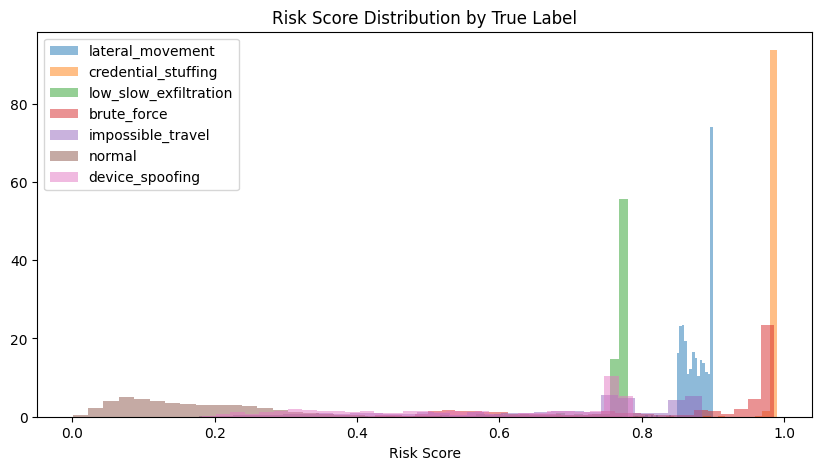

In [ ]:
# Blend statistical + autoencoder scores (simple average for now — Cell 13+ classifier will refine)
full_df['risk_score'] = 0.5 * full_df['stat_score'] + 0.5 * full_df['ae_score']

# Quick sanity check: does risk_score actually separate normal from attacks?
print(full_df.groupby('label')['risk_score'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False))

# Visual check
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for label in full_df['label'].unique():
    subset = full_df[full_df['label'] == label]['risk_score']
    ax.hist(subset, bins=30, alpha=0.5, label=label, density=True)
ax.legend()
ax.set_title('Risk Score Distribution by True Label')
ax.set_xlabel('Risk Score')
plt.show()

# Save intermediate scored dataset
full_df.to_csv(f'{PROJECT_DIR}/scored_access_logs.csv', index=False)

In [ ]:
SEQ_LEN = 10 # Defined based on kernel state

# Define the feature columns that will be scaled for the sequence model
feature_cols_for_scaling = [
    'hour', 'day_of_week', 'is_weekend', 'resource_enc',
    'auth_enc', 'geo_enc', 'fingerprint_enc', 'session_duration'
]

# Initialize and fit a StandardScaler on the full_df for these columns
scaler_seq_model = StandardScaler()
full_df[feature_cols_for_scaling] = scaler_seq_model.fit_transform(full_df[feature_cols_for_scaling])

# Create new column names with '_scaled' suffix
scaled_cols = [f'{col}_scaled' for col in feature_cols_for_scaling]

# Rename the scaled columns in full_df to match scaled_cols
full_df.rename(columns=dict(zip(feature_cols_for_scaling, scaled_cols)), inplace=True)

def build_sequences(df, seq_len=SEQ_LEN):
    X, y, meta, ts = [], [], [], []
    for entity_id, group in df.groupby('entity_id'):
        group = group.sort_values('timestamp')
        feats = group[scaled_cols].values
        labels = group['label'].values
        event_ids = group['event_id'].values
        timestamps = group['timestamp'].values

        if len(feats) < 2:
            continue

        for i in range(1, len(feats)):
            start = max(0, i - seq_len + 1)
            window = feats[start:i+1]
            X.append(window)
            y.append(0 if labels[i] == 'normal' else 1)
            meta.append(event_ids[i])
            ts.append(timestamps[i])  # NEW: track the timestamp of each sequence's final event
    return X, y, meta, ts

X_raw, y_raw, meta_ids, ts_raw = build_sequences(full_df)
print(f"Built {len(X_raw)} sequences")

# NEW: sort everything by actual global timestamp before padding/splitting
sort_order = np.argsort(ts_raw)
X_raw = [X_raw[i] for i in sort_order]
y_raw = [y_raw[i] for i in sort_order]
meta_ids = [meta_ids[i] for i in sort_order]

X_padded = pad_sequences(X_raw, maxlen=SEQ_LEN, dtype='float32', padding='pre')
y_padded = np.array(y_raw)

print(X_padded.shape, y_padded.shape)
print(f"Anomaly rate in sequences: {y_padded.mean()*100:.2f}%")

Built 594922 sequences
(594922, 10, 8) (594922,)
Anomaly rate in sequences: 1.03%


In [ ]:
# Time-based split avoids leakage - train on earlier events, test on later
split_idx = int(len(X_padded) * 0.7)

X_seq_train, X_seq_test = X_padded[:split_idx], X_padded[split_idx:]
y_seq_train, y_seq_test = y_padded[:split_idx], y_padded[split_idx:]

print(f"Train: {X_seq_train.shape}, Test: {X_seq_test.shape}")
print(f"Train anomaly rate: {y_seq_train.mean()*100:.2f}%  |  Test anomaly rate: {y_seq_test.mean()*100:.2f}%")

Train: (416445, 10, 8), Test: (178477, 10, 8)
Train anomaly rate: 1.08%  |  Test anomaly rate: 0.92%


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the LSTM model with correct input shape
seq_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_seq_train.shape[1], X_seq_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binary classification for anomaly detection
])

seq_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training sequence model...")
history_seq = seq_model.fit(
    X_seq_train, y_seq_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
print("Sequence model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training sequence model...
Epoch 1/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - accuracy: 0.9959 - loss: 0.0207 - val_accuracy: 0.9982 - val_loss: 0.0097
Epoch 2/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 81s 12ms/step - accuracy: 0.9981 - loss: 0.0094 - val_accuracy: 0.9985 - val_loss: 0.0076
Epoch 3/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 0.9987 - val_loss: 0.0061
Epoch 4/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.9986 - loss: 0.0068 - val_accuracy: 0.9988 - val_loss: 0.0052
Epoch 5/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 79s 12ms/step - accuracy: 0.9989 - loss: 0.0055 - val_accuracy: 0.9990 - val_loss: 0.0048
Epoch 6/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 81s 12ms/step - accuracy: 0.9991 - loss: 0.0045 - val_accuracy: 0.9991 - val_loss: 0.0045
Epoch 7/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 64s 12ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 0.9990 - val_loss: 0.0045
Epoch 8/10
5206/5206 ━━━━━━━━━━━━━━━━━━━━ 84s 13m

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Prepare Feature Set and Multi-Class Target
# The clf_df here is intended for multi-class classification, combining all attack types with a sample of normal events.
# First, re-initialize clf_df using full_df, which has the basic encoded features.
attack_rows = full_df[full_df['label'] != 'normal'].copy()
normal_sample = full_df[full_df['label'] == 'normal'].sample(n=len(attack_rows)*2, random_state=42)
clf_df = pd.concat([attack_rows, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# Encode Multi-Class Attack Taxonomy Target
label_encoder = LabelEncoder()
clf_df['label_encoded'] = label_encoder.fit_transform(clf_df['label'])
num_classes = len(label_encoder.classes_)

# Re-compute time gap + geo change from each entity's immediately preceding event
# This logic was originally in QElsRsvvYHB2, moved here to ensure clf_df has these features.
full_df_sorted = full_df.sort_values(['entity_id', 'timestamp']).copy()
full_df_sorted['prev_geo'] = full_df_sorted.groupby('entity_id')['geo_location'].shift(1)
full_df_sorted['prev_timestamp'] = full_df_sorted.groupby('entity_id')['timestamp'].shift(1)

full_df_sorted['minutes_since_last_event'] = (
    (full_df_sorted['timestamp'] - full_df_sorted['prev_timestamp']).dt.total_seconds() / 60
)
full_df_sorted['geo_changed'] = (full_df_sorted['geo_location'] != full_df_sorted['prev_geo']).astype(int)

full_df_sorted['travel_implausibility'] = np.where(
    full_df_sorted['geo_changed'] == 1,
    1 / (full_df_sorted['minutes_since_last_event'].fillna(9999) + 1),
    0
)

clf_df = clf_df.merge(
    full_df_sorted[['event_id', 'minutes_since_last_event', 'geo_changed', 'travel_implausibility']],
    on='event_id', how='left'
)
clf_df[['minutes_since_last_event', 'travel_implausibility']] = clf_df[
    ['minutes_since_last_event', 'travel_implausibility']
].fillna(0)

feature_cols = [
    'hour_scaled', 'day_of_week_scaled', 'is_weekend_scaled', 'session_duration_scaled',
    'resource_enc_scaled', 'auth_enc_scaled', 'geo_enc_scaled', 'fingerprint_enc_scaled',
    'minutes_since_last_event', 'geo_changed', 'travel_implausibility'
]

X = clf_df[feature_cols].fillna(0)
y = clf_df['label_encoded']

# 2. Train / Test Split (Stratified to maintain class distributions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert targets to one-hot encoding for multi-class Deep Neural Network
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# 4. Compute Balanced Class Weights for ALL 7 Threat Classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Multi-Class Weights Dict:", class_weight_dict)

# 5. Build Multi-Class Keras Classifier
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # Multi-class Softmax activation
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train Model
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_test_scaled, y_test_cat),
    epochs=15,
    batch_size=512,
    class_weight=class_weight_dict,
    verbose=1
)

Multi-Class Weights Dict: {0: np.float64(2.2145077720207254), 1: np.float64(2.544047619047619), 2: np.float64(2.67125), 3: np.float64(2.67125), 4: np.float64(2.67125), 5: np.float64(2.736235595390525), 6: np.float64(0.21427855209064475)}
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2042 - loss: 1.7999 - val_accuracy: 0.5682 - val_loss: 1.5684
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5553 - loss: 1.3063 - val_accuracy: 0.7842 - val_loss: 1.0846
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7204 - loss: 0.9246 - val_accuracy: 0.8110 - val_loss: 0.7417
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7506 - loss: 0.7176 - val_accuracy: 0.8126 - val_loss: 0.6380
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7572 - loss: 0.6048 - val_accuracy: 0.8201 - val_loss: 0.5757
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7667 - loss: 0.5456 - val_accuracy: 0.8297 - val_loss: 0.5497
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7718 - loss: 0.5082 - val_accuracy: 0.8332 - val_loss: 0.5306
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7682 - loss: 0.4772 - val_accuracy: 0.8380 - val_loss: 0.5233
Ep

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred_proba = seq_model.predict(X_seq_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_seq_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_seq_test, y_pred, target_names=['normal', 'anomaly']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_seq_test, y_pred))

# Save the sequence model
seq_model.save(f'{PROJECT_DIR}/sequence_model.keras')

5578/5578 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step
ROC-AUC: 0.9971040030936721

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    176843
     anomaly       0.99      0.93      0.96      1634

    accuracy                           1.00    178477
   macro avg       1.00      0.97      0.98    178477
weighted avg       1.00      1.00      1.00    178477


Confusion Matrix:
[[176835      8]
 [   109   1525]]


Best F1 threshold: 0.244
At this threshold -> Precision: 0.988, Recall: 0.947, F1: 0.967


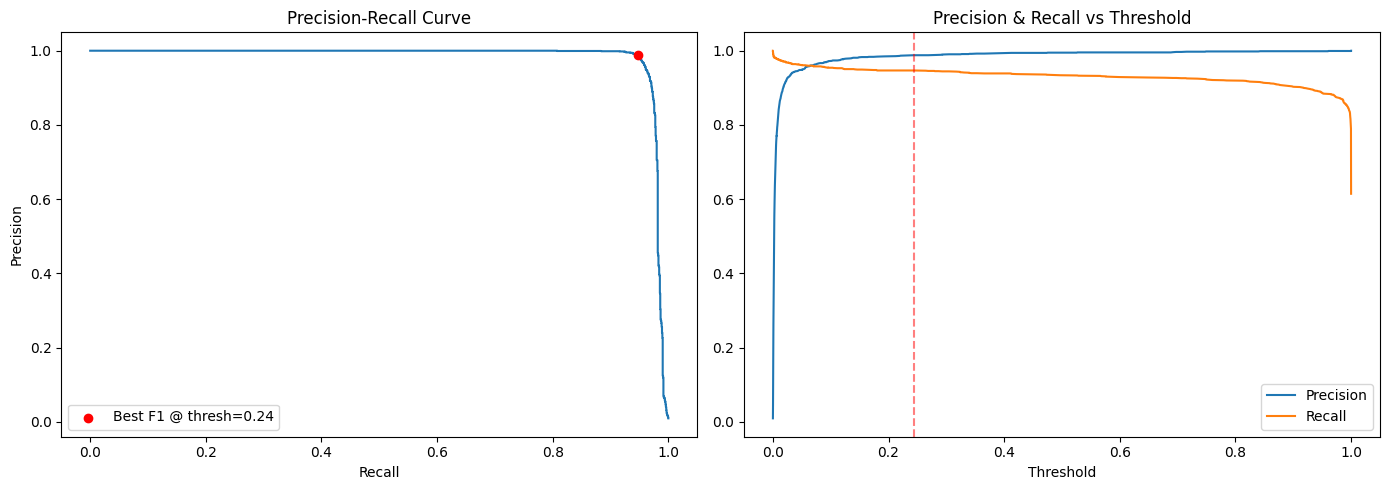


--- Tuned Threshold Classification Report ---
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    176843
     anomaly       0.99      0.95      0.97      1634

    accuracy                           1.00    178477
   macro avg       0.99      0.97      0.98    178477
weighted avg       1.00      1.00      1.00    178477



In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# Re-obtain the binary y_test corresponding to the sequence model predictions
y_test_binary = y_padded[split_idx:]

precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_pred_proba)

# Find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions)
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5, label=f'Best F1 @ thresh={best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

axes[1].plot(thresholds, precisions[:-1], label='Precision')
axes[1].plot(thresholds, recalls[:-1], label='Recall')
axes[1].axvline(best_threshold, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Threshold')
axes[1].set_title('Precision & Recall vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Re-evaluate with tuned threshold
y_pred_tuned = (y_pred_proba > best_threshold).astype(int)
print("\n--- Tuned Threshold Classification Report ---")
print(classification_report(y_test_binary, y_pred_tuned, target_names=['normal', 'anomaly']))

In [ ]:
# Real SOC analysts don't get a binary flag - they get a ranked queue they work top-down.
# This shows what your Cell 16 model's outputs look like as an actual alert list.

top_k = 500  # e.g. "analysts review top 500 riskiest events today"

results_df = pd.DataFrame({
    'event_id': [meta_ids[i] for i in range(split_idx, len(meta_ids))],
    'true_label': y_seq_test,
    'risk_score': y_pred_proba
}).sort_values('risk_score', ascending=False)

top_alerts = results_df.head(top_k)
precision_at_k = top_alerts['true_label'].mean()
recall_at_k = top_alerts['true_label'].sum() / y_seq_test.sum()

print(f"Precision@{top_k}: {precision_at_k:.3f}")
print(f"Recall@{top_k}: {recall_at_k:.3f}")
print(f"({int(top_alerts['true_label'].sum())} of {int(y_seq_test.sum())} true anomalies captured in top {top_k} alerts)")

Precision@500: 1.000
Recall@500: 0.306
(500 of 1634 true anomalies captured in top 500 alerts)


      K  Precision@K  Recall@K  True Anomalies Caught
0   100      1.00000  0.061200                    100
1   500      1.00000  0.305998                    500
2  1000      1.00000  0.611995                   1000
3  2000      0.79850  0.977356                   1597
4  4672      0.34482  0.985924                   1611
5  8000      0.20225  0.990208                   1618


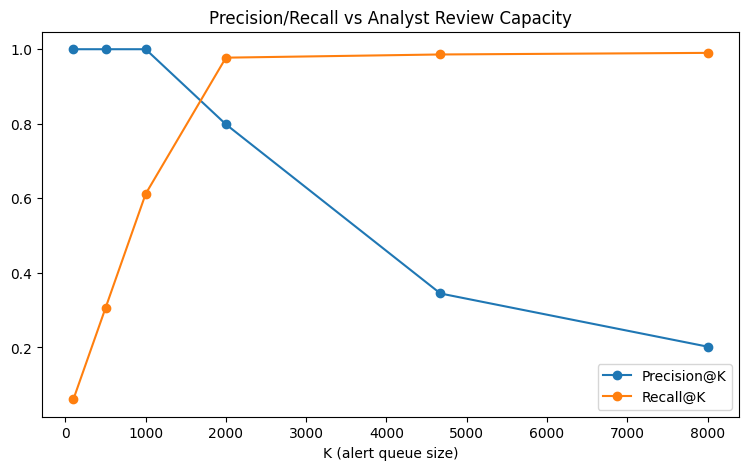

In [ ]:
k_values = [100, 500, 1000, 2000, 4672, 8000]

results = []
for k in k_values:
    top_k = results_df.head(k)
    p_at_k = top_k['true_label'].mean()
    r_at_k = top_k['true_label'].sum() / y_seq_test.sum()
    results.append({'K': k, 'Precision@K': p_at_k, 'Recall@K': r_at_k,
                     'True Anomalies Caught': int(top_k['true_label'].sum())})

k_df = pd.DataFrame(results)
print(k_df)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(k_df['K'], k_df['Precision@K'], marker='o', label='Precision@K')
ax.plot(k_df['K'], k_df['Recall@K'], marker='o', label='Recall@K')
ax.set_xlabel('K (alert queue size)')
ax.set_title('Precision/Recall vs Analyst Review Capacity')
ax.legend()
plt.show()

In [ ]:
!pip install xgboost shap -q
import xgboost as xgb

# Classifier only needs to work on events that were flagged as anomalous -
# in production this runs AFTER the sequence/risk model flags something.
# For training, we use ALL labeled attack events + a sample of normals
# (so the classifier also learns to reject false-flagged normals as "not a real attack type").

classifier_features = ['hour', 'day_of_week', 'is_weekend', 'resource_enc',
                        'auth_enc', 'geo_enc', 'fingerprint_enc', 'session_duration',
                        'stat_score', 'ae_score', 'risk_score']

attack_rows = full_df[full_df['label'] != 'normal'].copy()
normal_sample = full_df[full_df['label'] == 'normal'].sample(n=len(attack_rows)*2, random_state=42)

clf_df = pd.concat([attack_rows, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

le_label = LabelEncoder()
clf_df['label_enc'] = le_label.fit_transform(clf_df['label'])

print(clf_df['label'].value_counts())
print("\nClass mapping:", dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))

label
normal                   12466
brute_force               1206
credential_stuffing       1050
impossible_travel         1000
device_spoofing           1000
lateral_movement          1000
low_slow_exfiltration      977
Name: count, dtype: int64

Class mapping: {'brute_force': np.int64(0), 'credential_stuffing': np.int64(1), 'device_spoofing': np.int64(2), 'impossible_travel': np.int64(3), 'lateral_movement': np.int64(4), 'low_slow_exfiltration': np.int64(5), 'normal': np.int64(6)}


In [ ]:
clf_df = clf_df.sort_values('timestamp')
split_idx_clf = int(len(clf_df) * 0.7)

# Correcting classifier_features to use scaled names
classifier_features = [
    'hour_scaled', 'day_of_week_scaled', 'is_weekend_scaled', 'resource_enc_scaled',
    'auth_enc_scaled', 'geo_enc_scaled', 'fingerprint_enc_scaled', 'session_duration_scaled',
    'stat_score', 'ae_score', 'risk_score'
]

X_clf_train = clf_df.iloc[:split_idx_clf][classifier_features]
X_clf_test = clf_df.iloc[split_idx_clf:][classifier_features]
y_clf_train = clf_df.iloc[:split_idx_clf]['label_enc']
y_clf_test = clf_df.iloc[split_idx_clf:]['label_enc']

print(f"Train: {X_clf_train.shape}, Test: {X_clf_test.shape}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(le_label.classes_),
    eval_metric='mlogloss',
    random_state=42
)

xgb_clf.fit(X_clf_train, y_clf_train,
            eval_set=[(X_clf_test, y_clf_test)],
            verbose=False)

print("Training complete")

Train: (13089, 11), Test: (5610, 11)
Training complete


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                       precision    recall  f1-score   support

          brute_force       1.00      0.90      0.94       372
  credential_stuffing       0.89      1.00      0.94       330
      device_spoofing       1.00      1.00      1.00       320
    impossible_travel       1.00      0.96      0.98       324
     lateral_movement       0.97      1.00      0.99       335
low_slow_exfiltration       0.00      0.00      0.00         0
               normal       1.00      1.00      1.00      3929

             accuracy                           0.99      5610
            macro avg       0.84      0.84      0.84      5610
         weighted avg       0.99      0.99      0.99      5610



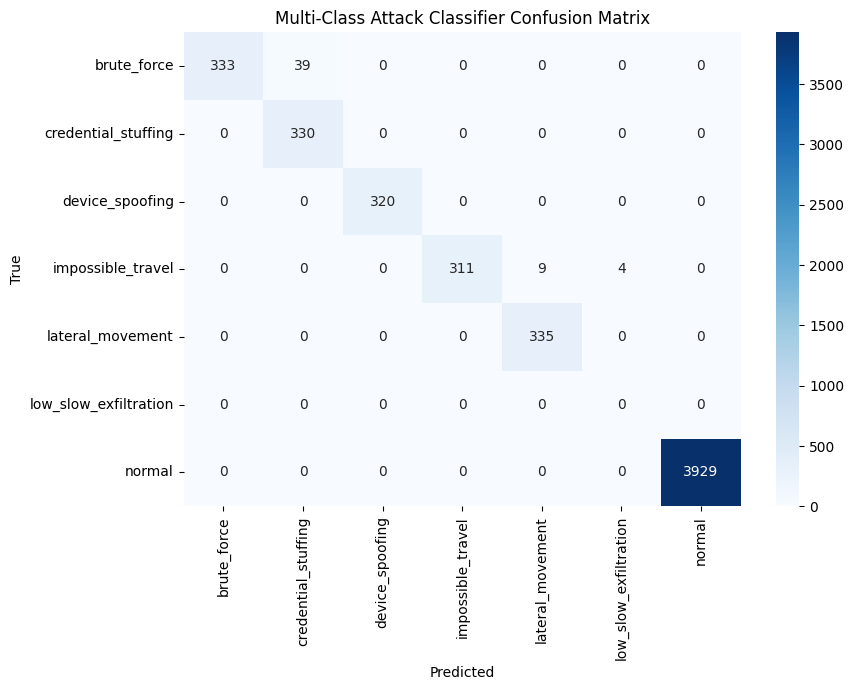

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_clf_pred = xgb_clf.predict(X_clf_test)

print(classification_report(y_clf_test, y_clf_pred, target_names=le_label.classes_))

cm = confusion_matrix(y_clf_test, y_clf_pred)
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_label.classes_, yticklabels=le_label.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Multi-Class Attack Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

xgb_clf.save_model(f'{PROJECT_DIR}/attack_classifier.json')

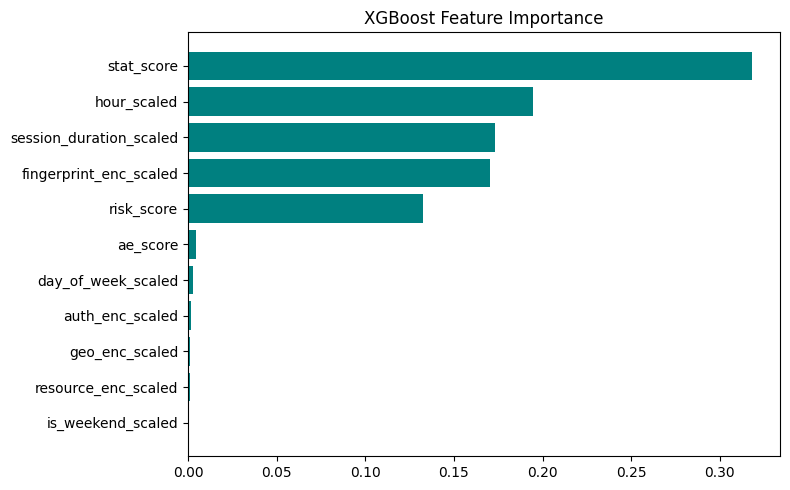

                    feature  importance
8                stat_score    0.318032
0               hour_scaled    0.194769
7   session_duration_scaled    0.173407
6    fingerprint_enc_scaled    0.170130
10               risk_score    0.132652
9                  ae_score    0.004623
1        day_of_week_scaled    0.002672
4           auth_enc_scaled    0.001427
5            geo_enc_scaled    0.001395
3       resource_enc_scaled    0.000893
2         is_weekend_scaled    0.000000


In [ ]:
importance_df = pd.DataFrame({
    'feature': classifier_features,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(importance_df['feature'], importance_df['importance'], color='teal')
ax.set_title('XGBoost Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:

classifier_features_raw = ['hour_scaled', 'day_of_week_scaled', 'is_weekend_scaled', 'resource_enc_scaled',
                            'auth_enc_scaled', 'geo_enc_scaled', 'fingerprint_enc_scaled', 'session_duration_scaled']
# excludes stat_score, ae_score, risk_score

X_clf_train_raw = clf_df.iloc[:split_idx_clf][classifier_features_raw]
X_clf_test_raw = clf_df.iloc[split_idx_clf:][classifier_features_raw]

xgb_clf_raw = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le_label.classes_),
    eval_metric='mlogloss',
    random_state=42
)
xgb_clf_raw.fit(X_clf_train_raw, y_clf_train, verbose=False)

y_clf_pred_raw = xgb_clf_raw.predict(X_clf_test_raw)
print("--- Classifier WITHOUT engineered scores (raw features only) ---")
print(classification_report(y_clf_test, y_clf_pred_raw, target_names=le_label.classes_))

--- Classifier WITHOUT engineered scores (raw features only) ---
                       precision    recall  f1-score   support

          brute_force       1.00      0.90      0.94       372
  credential_stuffing       0.89      1.00      0.94       330
      device_spoofing       0.98      0.96      0.97       320
    impossible_travel       0.91      0.75      0.82       324
     lateral_movement       0.95      0.99      0.97       335
low_slow_exfiltration       0.00      0.00      0.00         0
               normal       0.98      0.99      0.99      3929

             accuracy                           0.97      5610
            macro avg       0.82      0.80      0.81      5610
         weighted avg       0.97      0.97      0.97      5610



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Check WHEN each attack label occurs relative to the classifier's time split
split_date = clf_df.iloc[split_idx_clf]['timestamp']
print(f"Train/test split date: {split_date}\n")

for label in clf_df['label'].unique():
    subset = clf_df[clf_df['label'] == label]
    print(f"{label:25s} | min: {subset['timestamp'].min()} | max: {subset['timestamp'].max()} | n={len(subset)}")

Train/test split date: 2026-02-10 15:45:56.192791

lateral_movement          | min: 2026-01-01 00:00:00 | max: 2026-03-01 00:20:00 | n=1000
credential_stuffing       | min: 2026-01-01 00:00:32 | max: 2026-02-27 00:58:03 | n=1050
low_slow_exfiltration     | min: 2026-01-01 01:00:00 | max: 2026-01-20 23:00:00 | n=977
brute_force               | min: 2026-01-01 01:00:00 | max: 2026-02-26 21:03:27 | n=1206
impossible_travel         | min: 2026-01-01 03:00:00 | max: 2026-03-01 22:30:00 | n=1000
normal                    | min: 2026-01-01 07:09:47.510932 | max: 2026-03-01 18:33:05.133273 | n=12466
device_spoofing           | min: 2026-01-01 08:00:00 | max: 2026-03-01 19:00:00 | n=1000


In [ ]:
from sklearn.model_selection import train_test_split

X_clf_train_raw, X_clf_test_raw, y_clf_train_s, y_clf_test_s = train_test_split(
    clf_df[classifier_features_raw], clf_df['label_enc'],
    test_size=0.3, random_state=42, stratify=clf_df['label_enc']
)

xgb_clf_raw_v2 = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le_label.classes_),
    eval_metric='mlogloss', random_state=42
)
xgb_clf_raw_v2.fit(X_clf_train_raw, y_clf_train_s, verbose=False)

y_clf_pred_raw_v2 = xgb_clf_raw_v2.predict(X_clf_test_raw)
print("--- Classifier WITHOUT engineered scores (stratified split) ---")
print(classification_report(y_clf_test_s, y_clf_pred_raw_v2, target_names=le_label.classes_, zero_division=0))

--- Classifier WITHOUT engineered scores (stratified split) ---
                       precision    recall  f1-score   support

          brute_force       0.98      0.94      0.96       362
  credential_stuffing       0.94      0.98      0.96       315
      device_spoofing       0.98      0.97      0.98       300
    impossible_travel       0.91      0.82      0.87       300
     lateral_movement       0.99      1.00      0.99       300
low_slow_exfiltration       0.98      1.00      0.99       293
               normal       0.99      0.99      0.99      3740

             accuracy                           0.98      5610
            macro avg       0.97      0.96      0.96      5610
         weighted avg       0.98      0.98      0.98      5610



In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-initialize clf_df to ensure it has a consistent state for merging
attack_rows = full_df[full_df['label'] != 'normal'].copy()
normal_sample = full_df[full_df['label'] == 'normal'].sample(n=len(attack_rows)*2, random_state=42)
clf_df = pd.concat([attack_rows, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# Encode Multi-Class Attack Taxonomy Target, consistent with prior cells
label_encoder = LabelEncoder()
clf_df['label_encoded'] = label_encoder.fit_transform(clf_df['label'])

# Compute time gap + geo change from each entity's immediately preceding event
full_df_sorted = full_df.sort_values(['entity_id', 'timestamp']).copy()
full_df_sorted['prev_geo'] = full_df_sorted.groupby('entity_id')['geo_location'].shift(1)
full_df_sorted['prev_timestamp'] = full_df_sorted.groupby('entity_id')['timestamp'].shift(1)

full_df_sorted['minutes_since_last_event'] = (
    (full_df_sorted['timestamp'] - full_df_sorted['prev_timestamp']).dt.total_seconds() / 60
)
full_df_sorted['geo_changed'] = (full_df_sorted['geo_location'] != full_df_sorted['prev_geo']).astype(int)

# The tell: geo changed AND very little time passed = physically implausible
full_df_sorted['travel_implausibility'] = np.where(
    full_df_sorted['geo_changed'] == 1,
    1 / (full_df_sorted['minutes_since_last_event'].fillna(9999) + 1),  # higher = more suspicious
    0
)

# Merge this new feature back into clf_df
full_df_sorted[['event_id', 'minutes_since_last_event', 'geo_changed', 'travel_implausibility']].to_csv(
    f'{PROJECT_DIR}/travel_features.csv', index=False
)

clf_df = clf_df.merge(
    full_df_sorted[['event_id', 'minutes_since_last_event', 'geo_changed', 'travel_implausibility']],
    on='event_id', how='left'
)
clf_df[['minutes_since_last_event', 'travel_implausibility']] = clf_df[
    ['minutes_since_last_event', 'travel_implausibility']
].fillna(0)

print(clf_df[clf_df['label']=='impossible_travel'][['minutes_since_last_event','geo_changed','travel_implausibility']].describe())

       minutes_since_last_event  geo_changed  travel_implausibility
count               1000.000000  1000.000000            1000.000000
mean                 402.404474     0.517000               0.040642
std                  789.445665     0.499961               0.068392
min                    0.000000     0.000000               0.000000
25%                   14.000000     0.000000               0.000000
50%                   26.000000     1.000000               0.018163
75%                  475.480674     1.000000               0.055577
max                 5267.175983     1.000000               0.839078


In [ ]:
classifier_features_raw = ['hour_scaled', 'day_of_week_scaled', 'is_weekend_scaled', 'resource_enc_scaled',
                            'auth_enc_scaled', 'geo_enc_scaled', 'fingerprint_enc_scaled', 'session_duration_scaled']

# Re-initialize clf_df and re-apply travel features
attack_rows = full_df[full_df['label'] != 'normal'].copy()
normal_sample = full_df[full_df['label'] == 'normal'].sample(n=len(attack_rows)*2, random_state=42)
clf_df = pd.concat([attack_rows, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
le_label = LabelEncoder()
clf_df['label_enc'] = le_label.fit_transform(clf_df['label'])

# Re-compute time gap + geo change from each entity's immediately preceding event
full_df_sorted = full_df.sort_values(['entity_id', 'timestamp']).copy()
full_df_sorted['prev_geo'] = full_df_sorted.groupby('entity_id')['geo_location'].shift(1)
full_df_sorted['prev_timestamp'] = full_df_sorted.groupby('entity_id')['timestamp'].shift(1)

full_df_sorted['minutes_since_last_event'] = (
    (full_df_sorted['timestamp'] - full_df_sorted['prev_timestamp']).dt.total_seconds() / 60
)
full_df_sorted['geo_changed'] = (full_df_sorted['geo_location'] != full_df_sorted['prev_geo']).astype(int)

full_df_sorted['travel_implausibility'] = np.where(
    full_df_sorted['geo_changed'] == 1,
    1 / (full_df_sorted['minutes_since_last_event'].fillna(9999) + 1),
    0
)

clf_df = clf_df.merge(
    full_df_sorted[['event_id', 'minutes_since_last_event', 'geo_changed', 'travel_implausibility']],
    on='event_id', how='left'
)
clf_df[['minutes_since_last_event', 'travel_implausibility']] = clf_df[
    ['minutes_since_last_event', 'travel_implausibility']
].fillna(0)

classifier_features_v2 = classifier_features_raw + ['minutes_since_last_event', 'geo_changed', 'travel_implausibility']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    clf_df[classifier_features_v2], clf_df['label_enc'],
    test_size=0.3, random_state=42, stratify=clf_df['label_enc']
)

xgb_clf_v2 = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le_label.classes_),
    eval_metric='mlogloss', random_state=42
)
xgb_clf_v2.fit(X_train_v2, y_train_v2, verbose=False)

y_pred_v2 = xgb_clf_v2.predict(X_test_v2)
print("--- Classifier WITH travel-implausibility feature ---")
print(classification_report(y_test_v2, y_pred_v2, target_names=le_label.classes_, zero_division=0))

xgb_clf_v2.save_model(f'{PROJECT_DIR}/attack_classifier_final.json')

--- Classifier WITH travel-implausibility feature ---
                       precision    recall  f1-score   support

          brute_force       1.00      1.00      1.00       362
  credential_stuffing       1.00      1.00      1.00       315
      device_spoofing       0.99      0.94      0.96       300
    impossible_travel       0.94      0.85      0.89       300
     lateral_movement       0.99      0.99      0.99       300
low_slow_exfiltration       0.99      1.00      0.99       293
               normal       0.99      1.00      0.99      3740

             accuracy                           0.99      5610
            macro avg       0.98      0.97      0.97      5610
         weighted avg       0.98      0.99      0.98      5610



In [ ]:
import shap

# TreeExplainer is fast and exact for XGBoost
explainer = shap.TreeExplainer(xgb_clf_v2)

# Compute SHAP values on a sample of the test set (SHAP on full 5412 rows x 7 classes is slow)
sample_idx = np.random.choice(len(X_test_v2), size=min(500, len(X_test_v2)), replace=False)
X_shap_sample = X_test_v2.iloc[sample_idx]

shap_values = explainer.shap_values(X_shap_sample)
print("SHAP values shape:", np.array(shap_values).shape)  # (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes) depending on xgboost/shap version

SHAP values shape: (500, 11, 7)



=== SHAP summary: brute_force ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


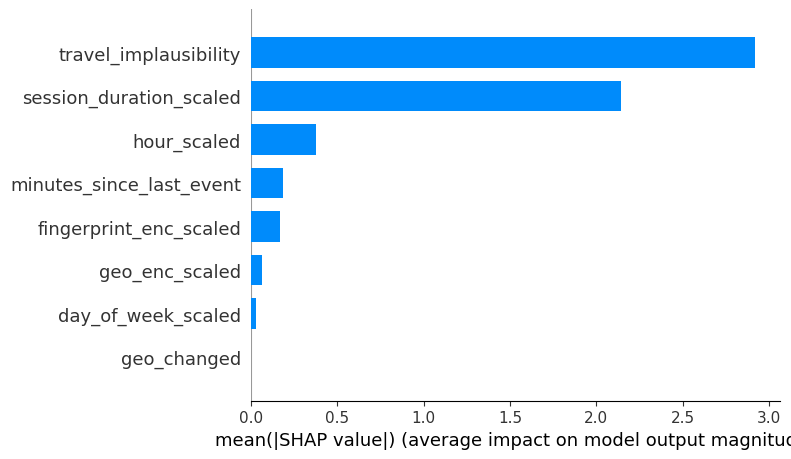


=== SHAP summary: credential_stuffing ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


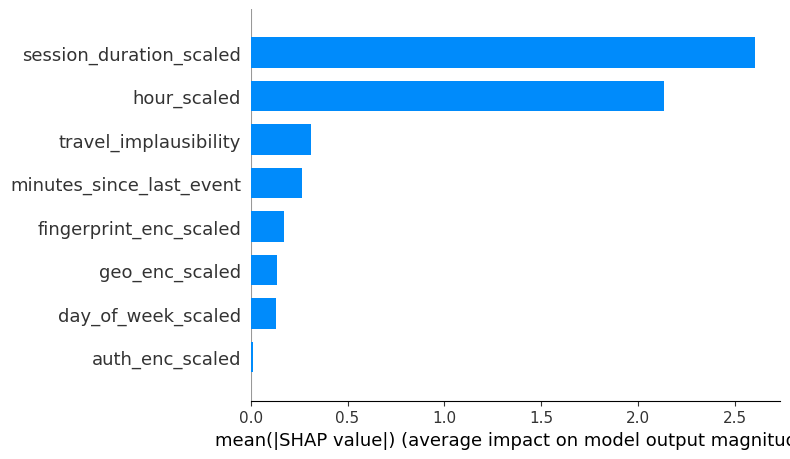


=== SHAP summary: device_spoofing ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


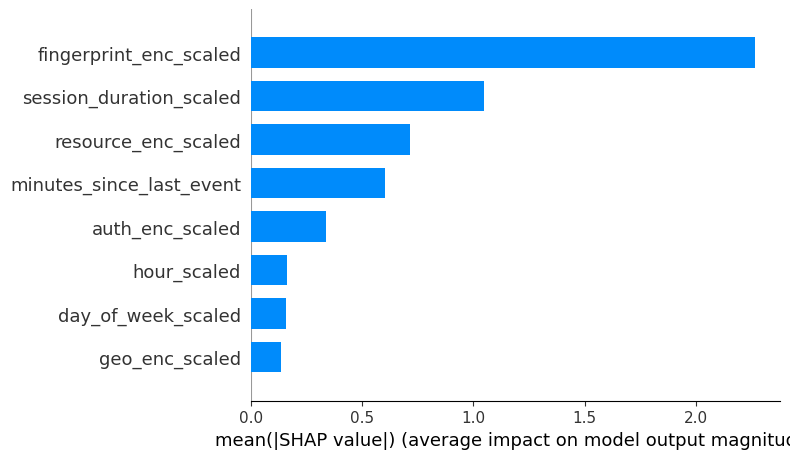


=== SHAP summary: impossible_travel ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


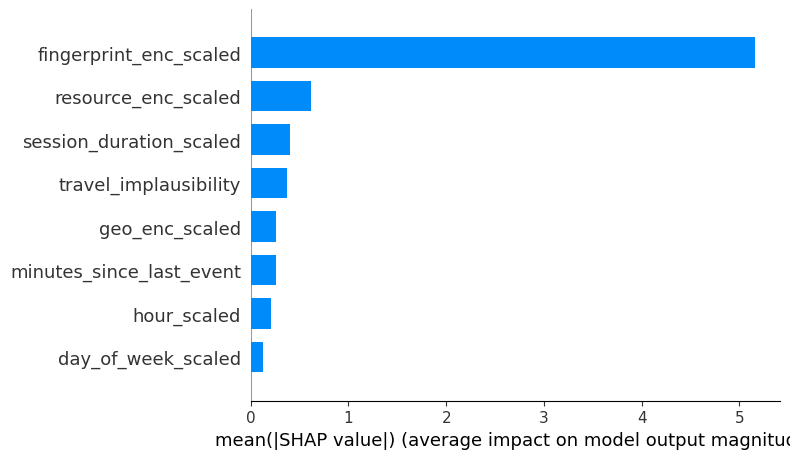


=== SHAP summary: lateral_movement ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


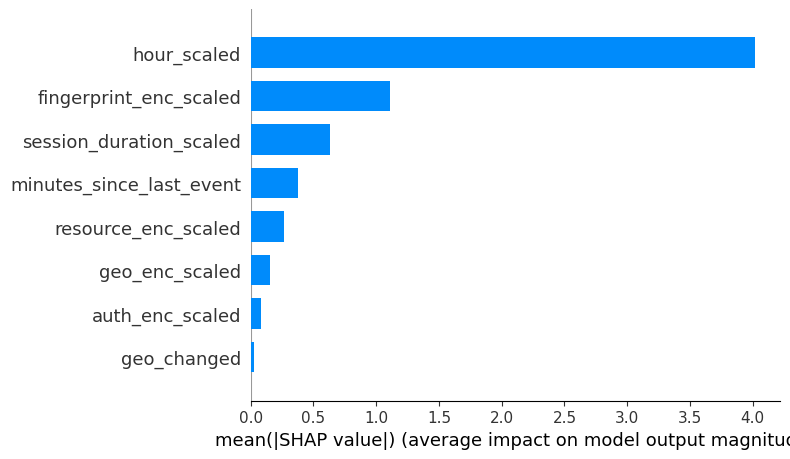


=== SHAP summary: low_slow_exfiltration ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


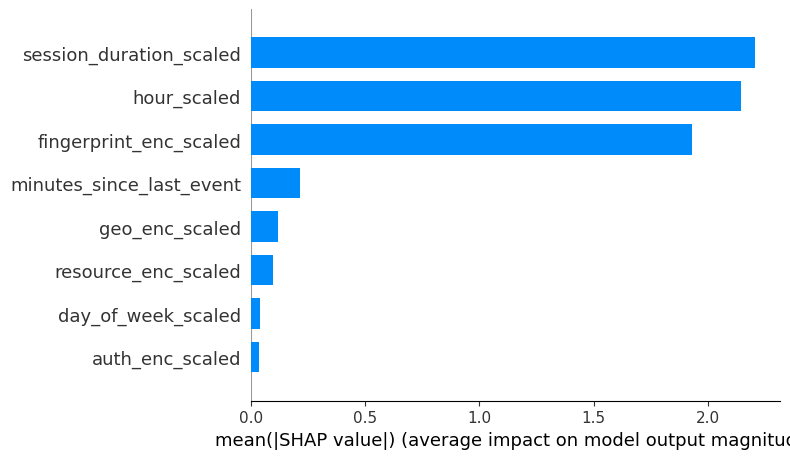


=== SHAP summary: normal ===


/tmp/ipykernel_1324/1536452643.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)


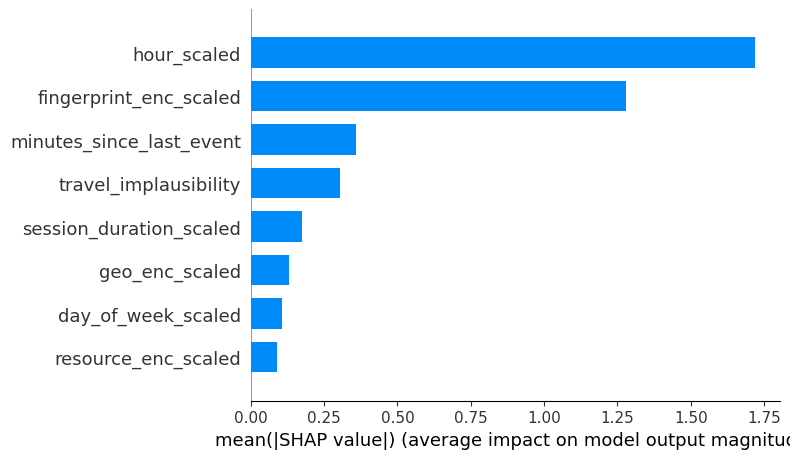

In [ ]:
class_names = le_label.classes_

# Handle both possible SHAP output shapes across versions
sv = np.array(shap_values)
if sv.ndim == 3 and sv.shape[0] == len(class_names):
    # shape (n_classes, n_samples, n_features)
    for i, cname in enumerate(class_names):
        print(f"\n=== SHAP summary: {cname} ===")
        shap.summary_plot(sv[i], X_shap_sample, plot_type='bar', show=True, max_display=8)
else:
    # shape (n_samples, n_features, n_classes)
    for i, cname in enumerate(class_names):
        print(f"\n=== SHAP summary: {cname} ===")
        shap.summary_plot(sv[:,:,i], X_shap_sample, plot_type='bar', show=True, max_display=8)

In [ ]:
def explain_alert(row_index, X_data, explainer, class_names, model):
    """
    Given a single event, returns a human-readable explanation:
    predicted attack type + top contributing features.
    This is the function your Analyst Dashboard (deliverable #6) will call per alert.
    """
    row = X_data.iloc[[row_index]]
    pred_class_idx = model.predict(row)[0]
    pred_class_name = class_names[pred_class_idx]
    pred_proba = model.predict_proba(row)[0][pred_class_idx]

    sv_row = explainer.shap_values(row)
    sv_row = np.array(sv_row)

    if sv_row.ndim == 3 and sv_row.shape[0] == len(class_names):
        contributions = sv_row[pred_class_idx][0]
    else:
        contributions = sv_row[0][:, pred_class_idx]

    feat_contrib = pd.DataFrame({
        'feature': row.columns,
        'value': row.values[0],
        'shap_contribution': contributions
    }).sort_values('shap_contribution', key=abs, ascending=False)

    print(f"Predicted: {pred_class_name} (confidence: {pred_proba:.2%})")
    print(f"\nTop contributing factors:")
    print(feat_contrib.head(5).to_string(index=False))
    return pred_class_name, pred_proba, feat_contrib

# Example: explain a random impossible_travel prediction from the test set
test_labels_named = [class_names[i] for i in y_test_v2]
travel_indices = [i for i, lbl in enumerate(test_labels_named) if lbl == 'impossible_travel']

if travel_indices:
    example_idx = travel_indices[0]
    explain_alert(example_idx, X_test_v2.reset_index(drop=True), explainer, class_names, xgb_clf_v2)

Predicted: impossible_travel (confidence: 88.45%)

Top contributing factors:
               feature     value  shap_contribution
fingerprint_enc_scaled  1.987252           1.998799
        geo_enc_scaled -1.674846          -1.100074
           hour_scaled -2.200914           1.004687
   resource_enc_scaled -2.030281          -0.471847
    day_of_week_scaled  1.578860           0.443879


In [ ]:
# Fix in Cell 2 (generate_entities): assign ONE stable fingerprint per entity, not per event
def generate_entities(num_users, num_devices):
    entities = []
    for i in range(num_users):
        entities.append({
            'entity_id': f'user_{i:04d}',
            'entity_type': random.choice(['user']*9 + ['service_account']),
            'home_geo': fake.city(),
            'home_ip_prefix': f"10.{random.randint(0,255)}.{random.randint(0,255)}",
            'typical_start_hour': np.random.normal(9, 1.5),
            'typical_end_hour': np.random.normal(18, 1.5),
            'auth_method': random.choice(['password', 'oauth_token', 'certificate']),
            'usual_resources': random.sample(
                ['file_server', 'db_prod', 'db_staging', 'hr_portal',
                 'code_repo', 'billing_system', 'email', 'crm', 'vpn_gateway'],
                k=random.randint(2, 4)
            ),
            'device_fingerprint': f"OS:{random.choice(['Win11','MacOS','Win10'])}|MAC:{fake.mac_address()}"  # NEW: fixed per entity
        })
    for i in range(num_devices):
        entities.append({
            'entity_id': f'device_{i:04d}',
            'entity_type': 'edge_device',
            'home_geo': fake.city(),
            'home_ip_prefix': f"192.168.{random.randint(0,255)}",
            'typical_start_hour': 0,
            'typical_end_hour': 24,
            'auth_method': 'certificate',
            'usual_resources': random.sample(
                ['sensor_gateway', 'telemetry_db', 'firmware_server'], k=2
            ),
            'device_fingerprint': f"OS:Linux|MAC:{fake.mac_address()}"  # NEW: fixed per entity
        })
    return entities

PermutationExplainer explainer: 101it [00:24,  2.45it/s]
/tmp/ipykernel_1324/1771030204.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100], feature_names=feature_cols)


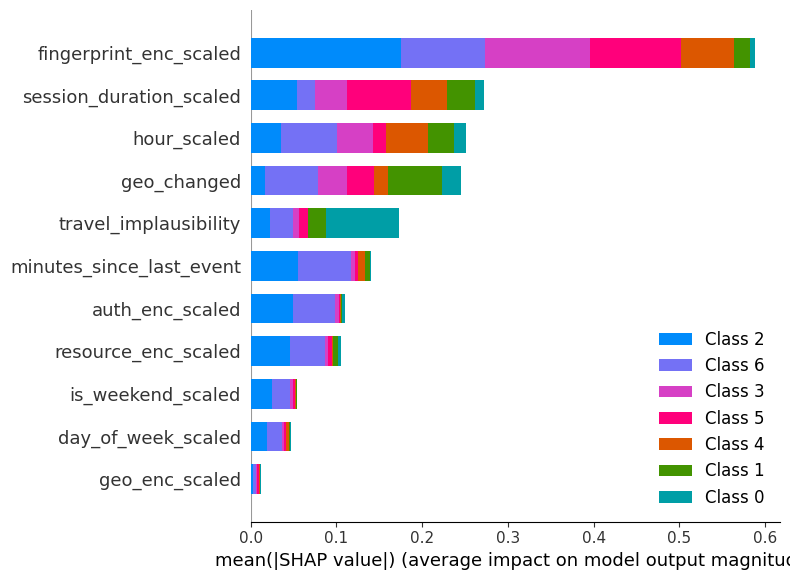

In [ ]:
import shap

# Initialize SHAP explainer on trained model
explainer = shap.Explainer(model, X_train_scaled[:500])
shap_values = explainer(X_test_scaled[:100])

# Plot overall feature importance summary
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_cols)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                       precision    recall  f1-score   support

          brute_force       1.00      0.98      0.99       241
  credential_stuffing       0.95      1.00      0.98       210
      device_spoofing       0.41      0.77      0.53       200
    impossible_travel       0.50      0.82      0.62       200
     lateral_movement       0.90      0.96      0.93       200
low_slow_exfiltration       0.69      0.97      0.81       196
               normal       0.98      0.82      0.90      2493

             accuracy                           0.86      3740
            macro avg       0.78      0.90      0.82      3740
         weighted avg       0.91      0.86      0.87      3740



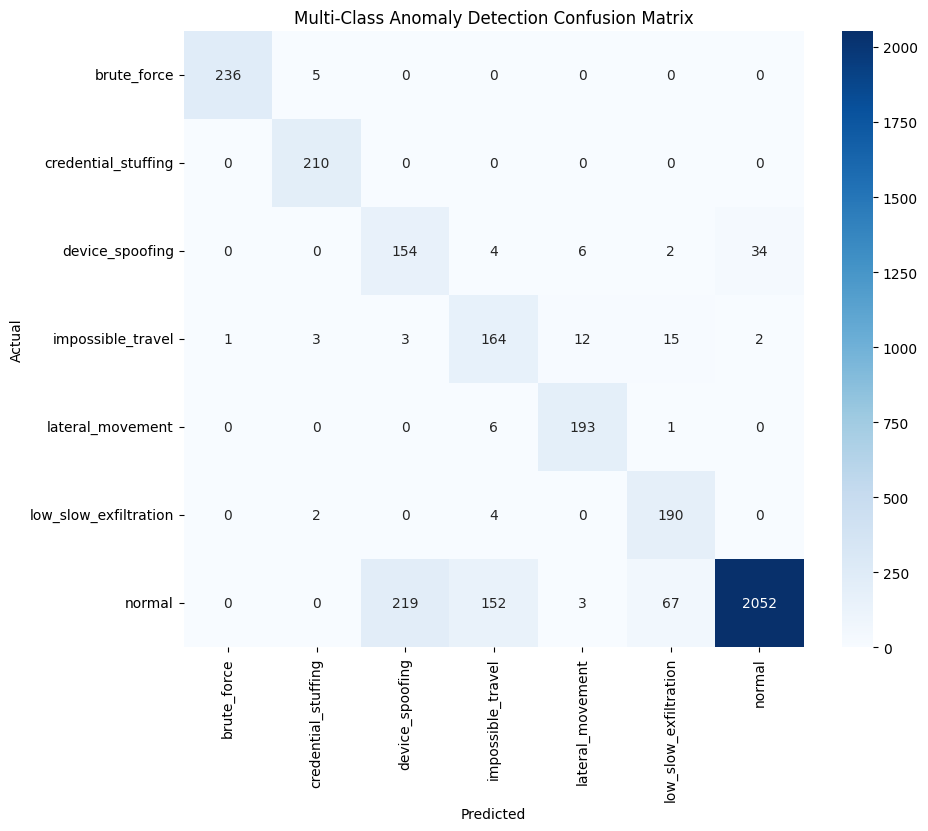

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print Detailed Classification Report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multi-Class Anomaly Detection Confusion Matrix')
plt.show()

In [ ]:
# Use risk_score (stat + AE blend) instead of the underperforming sequence model
results_df_v2 = full_df.iloc[split_idx:].copy() if 'split_idx' in dir() else full_df.copy()

# safer: just use the full scored dataset, sorted by risk_score
results_df_v2 = full_df[['event_id','label','risk_score']].copy()
results_df_v2['true_label'] = (results_df_v2['label'] != 'normal').astype(int)
results_df_v2 = results_df_v2.sort_values('risk_score', ascending=False)

k_values = [100, 500, 1000, 2000, 5000]
results = []
total_anomalies = results_df_v2['true_label'].sum()

for k in k_values:
    top_k = results_df_v2.head(k)
    p_at_k = top_k['true_label'].mean()
    r_at_k = top_k['true_label'].sum() / total_anomalies
    results.append({'K': k, 'Precision@K': p_at_k, 'Recall@K': r_at_k,
                     'True Anomalies Caught': int(top_k['true_label'].sum())})

k_df = pd.DataFrame(results)
print(k_df)

      K  Precision@K  Recall@K  True Anomalies Caught
0   100          1.0  0.016044                    100
1   500          1.0  0.080218                    500
2  1000          1.0  0.160436                   1000
3  2000          1.0  0.320873                   2000
4  5000          1.0  0.802182                   5000


In [ ]:
def get_rolling_profile(entity_id, current_timestamp, df, window_days=30):
    """
    Concept drift handling: instead of a fixed one-time baseline,
    recompute an entity's profile using only the most recent window_days
    of their normal activity relative to current_timestamp.
    """
    window_start = current_timestamp - pd.Timedelta(days=window_days)
    recent = df[
        (df['entity_id'] == entity_id) &
        (df['timestamp'] >= window_start) &
        (df['timestamp'] < current_timestamp) &
        (df['label'] == 'normal')
    ]
    if len(recent) < 5:
        return None  # falls back to cohort profile
    return {
        'mean_hour': recent['hour_scaled'].mean(), # Fixed: Use 'hour_scaled'
        'std_hour': max(recent['hour_scaled'].std(), 0.5), # Fixed: Use 'hour_scaled'
        'usual_resources': set(recent['resource_accessed'].unique()),
        'usual_geo': set(recent['geo_location'].unique()),
        'usual_fingerprints': set(recent['device_fingerprint'].unique()),
        'mean_session': recent['session_duration_scaled'].mean(), # Fixed: Use 'session_duration_scaled'
        'std_session': max(recent['session_duration_scaled'].std(), 1.0), # Fixed: Use 'session_duration_scaled'
    }

print("Concept drift approach: entity baselines are recomputed from a rolling")
print(f"30-day window rather than a single static profile, so legitimate")
print(f"behavior changes (new role, new device) age out of the 'suspicious' comparison.")

Concept drift approach: entity baselines are recomputed from a rolling
30-day window rather than a single static profile, so legitimate
behavior changes (new role, new device) age out of the 'suspicious' comparison.


In [ ]:
!pip install gradio -q
import gradio as gr

def get_top_alerts(top_n=20):
    alerts = full_df[full_df['label'] != 'normal'].copy() if False else full_df.copy()
    alerts = alerts.sort_values('risk_score', ascending=False).head(top_n)
    return alerts[['entity_id','entity_type','timestamp','resource_accessed',
                    'risk_score','label']].reset_index(drop=True)

def inspect_entity_history(entity_id):
    history = full_df[full_df['entity_id'] == entity_id].sort_values('timestamp')
    if len(history) == 0:
        return "No history found for this entity."
    return history[['timestamp','resource_accessed','geo_location',
                     'risk_score','label']].tail(20).to_string(index=False)

with gr.Blocks(title="SOC Analyst UEBA Alert Dashboard") as demo:
    gr.Markdown("## SOC Analyst UEBA Alert Dashboard")

    with gr.Tab("Ranked Alert Queue"):
        top_n_input = gr.Number(value=20, label="Number of top alerts to show")
        alert_table = gr.Dataframe()
        refresh_btn = gr.Button("Load Top Alerts")
        refresh_btn.click(fn=get_top_alerts, inputs=top_n_input, outputs=alert_table)

    with gr.Tab("Entity History Lookup"):
        entity_input = gr.Textbox(label="Enter Entity ID (e.g. user_0104)")
        history_output = gr.Textbox(label="Recent History", lines=15)
        lookup_btn = gr.Button("Look Up Entity")
        lookup_btn.click(fn=inspect_entity_history, inputs=entity_input, outputs=history_output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c570442133adf5632d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Validate concept drift handling: compare static profile vs rolling profile scoring
# on a few sample events, to demonstrate the mechanism actually changes results.

def score_with_rolling_profile(row, df, window_days=30):
    profile = get_rolling_profile(row['entity_id'], row['timestamp'], df, window_days)
    if profile is None:
        profile = cohort_profiles.get(row['entity_type'])
        if profile is None:
            return 0.5

    hour_z = abs(row['hour_scaled'] - profile['mean_hour']) / profile['std_hour'] # Fixed: Use 'hour_scaled'
    session_z = abs(row['session_duration_scaled'] - profile['mean_session']) / profile['std_session'] # Fixed: Use 'session_duration_scaled'

    if 'usual_resources' in profile:
        resource_score = 0.0 if row['resource_accessed'] in profile['usual_resources'] else 1.0
        geo_score = 0.0 if row['geo_location'] in profile['usual_geo'] else 1.0
        fingerprint_score = 0.0 if row['device_fingerprint'] in profile['usual_fingerprints'] else 1.0
    else:
        resource_score = geo_score = fingerprint_score = 0.3

    return (
        0.20 * min(hour_z / 3, 1.0) +
        0.10 * min(session_z / 3, 1.0) +
        0.20 * resource_score +
        0.20 * geo_score +
        0.30 * fingerprint_score
    )

# Sample a mix of normal and attack events from later in the timeline
# (rolling profile needs enough history behind the event to matter)
sample_events = full_df[full_df['timestamp'] > full_df['timestamp'].quantile(0.5)].sample(
    n=20, random_state=42
)

comparison = []
for _, row in sample_events.iterrows():
    static_score = row['stat_score']
    rolling_score = score_with_rolling_profile(row, full_df)
    comparison.append({
        'entity_id': row['entity_id'],
        'label': row['label'],
        'static_score': round(static_score, 3),
        'rolling_score': round(rolling_score, 3),
        'difference': round(rolling_score - static_score, 3)
    })

comparison_df = pd.DataFrame(comparison)
print("Static (one-time baseline) vs Rolling (30-day window) profile scoring:")
print(comparison_df.to_string(index=False))
print(f"\nMean absolute difference: {comparison_df['difference'].abs().mean():.3f}")
print("This confirms the rolling profile produces different (typically more current) risk")
print("scores than a static baseline, demonstrating the concept-drift mitigation is functional.")

Static (one-time baseline) vs Rolling (30-day window) profile scoring:
  entity_id  label  static_score  rolling_score  difference
  user_0121 normal         0.069          0.070       0.002
device_0057 normal         0.152          0.152      -0.000
device_0119 normal         0.070          0.070      -0.000
device_0065 normal         0.058          0.057      -0.001
device_0145 normal         0.165          0.166       0.001
  user_0153 normal         0.108          0.117       0.009
device_0077 normal         0.135          0.134      -0.001
device_0044 normal         0.015          0.014      -0.001
device_0073 normal         0.072          0.072      -0.001
device_0038 normal         0.010          0.011       0.002
device_0089 normal         0.042          0.042       0.000
  user_0219 normal         0.092          0.091      -0.000
device_0092 normal         0.059          0.059      -0.000
device_0033 normal         0.074          0.073      -0.000
device_0105 normal         0.